In [24]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1
import seaborn as sns

print(f"Python:     {sys.version}")
print(f"FastF1:     {fastf1.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"pandas:     {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")

Python:     3.14.6 (main, Jun 23 2026, 15:46:31) [Clang 22.1.3 ]
FastF1:     3.8.3
NumPy:      2.5.3
pandas:     2.3.3
Matplotlib: 3.11.2


In [17]:
from pathlib import Path

parent = Path.cwd()
cache_dir=parent.parent / 'f1_cache'


fastf1.Cache.enable_cache(cache_dir) 
fastf1.set_log_level("DEBUG")

In [18]:
session = fastf1.get_session(2026, "Australia", "R")

session.load(
    laps=False,
    telemetry=False,
    weather=False,
    messages=False,
)

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
_api          DEBUG 	Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
logger      WARNING 	Failed to load session info data!
logger        DEBUG 	Traceback for failure in session info data
Traceback (most recent call last):
  File "/Users/max/Projects/f1_lab/.venv/lib/python3.14/site-packages/fastf1/logger.py", line 112, in __wrapped
    return func(*args, **kwargs)
  File "/Users/max/Projects/f1_lab/.venv/lib/python3.14/site-packages/fastf1/core.py", line 1452, in _load_session_info
    self._session_info = api.session_info(self.api_path,
                         ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^
                                          livedata=livedata)
                                          ^^^^^^^^^^^^^^^^^^
  File "/Users/max/Projects/f1_lab/.venv/lib/pyt

In [19]:
results = session.results.sort_values("Position")

for row in results.head(10).itertuples():
    print(f"{int(row.Position)}. {row.FullName} ({row.TeamName})")

1. George Russell (Mercedes)
2. Andrea Kimi Antonelli (Mercedes)
3. Charles Leclerc (Ferrari)
4. Lewis Hamilton (Ferrari)
5. Lando Norris (McLaren)
6. Max Verstappen (Red Bull)
7. Oliver Bearman (Haas F1 Team)
8. Arvid Lindblad (RB F1 Team)
9. Gabriel Bortoleto (Audi)
10. Pierre Gasly (Alpine F1 Team)


# Full test

In [20]:
session = fastf1.get_session(2021, "Monaco", "R")

session.load(
    # laps=False,
    # telemetry=False,
    # weather=False,
    # messages=False,
)

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 16)
core        WARNING 	Driver 33 completed the race distance 00:00.058000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Fini

In [21]:
session.results

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
33,33,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,0600EF,red_bull,Max,Verstappen,Max Verstappen,...,1.0,1,2.0,NaT,NaT,NaT,0 days 01:38:56.820000,Finished,25.0,78.0
55,55,C SAINZ,SAI,sainz,Ferrari,DC0004,ferrari,Carlos,Sainz,Carlos Sainz,...,2.0,2,4.0,NaT,NaT,NaT,0 days 00:00:08.968000,Finished,18.0,78.0
4,4,L NORRIS,NOR,norris,McLaren,FF9800,mclaren,Lando,Norris,Lando Norris,...,3.0,3,5.0,NaT,NaT,NaT,0 days 00:00:19.427000,Finished,15.0,78.0
11,11,S PEREZ,PER,perez,Red Bull Racing,0600EF,red_bull,Sergio,Perez,Sergio Perez,...,4.0,4,9.0,NaT,NaT,NaT,0 days 00:00:20.490000,Finished,12.0,78.0
5,5,S VETTEL,VET,vettel,Aston Martin,006F62,aston_martin,Sebastian,Vettel,Sebastian Vettel,...,5.0,5,8.0,NaT,NaT,NaT,0 days 00:00:52.591000,Finished,10.0,78.0
10,10,P GASLY,GAS,gasly,AlphaTauri,2B4562,alphatauri,Pierre,Gasly,Pierre Gasly,...,6.0,6,6.0,NaT,NaT,NaT,0 days 00:00:53.896000,Finished,8.0,78.0
44,44,L HAMILTON,HAM,hamilton,Mercedes,00D2BE,mercedes,Lewis,Hamilton,Lewis Hamilton,...,7.0,7,7.0,NaT,NaT,NaT,0 days 00:01:08.231000,Finished,7.0,78.0
18,18,L STROLL,STR,stroll,Aston Martin,006F62,aston_martin,Lance,Stroll,Lance Stroll,...,8.0,8,13.0,NaT,NaT,NaT,NaT,+1 Lap,4.0,77.0
31,31,E OCON,OCO,ocon,Alpine,0090FF,alpine,Esteban,Ocon,Esteban Ocon,...,9.0,9,11.0,NaT,NaT,NaT,NaT,+1 Lap,2.0,77.0
99,99,A GIOVINAZZI,GIO,giovinazzi,Alfa Romeo Racing,900000,alfa,Antonio,Giovinazzi,Antonio Giovinazzi,...,10.0,10,10.0,NaT,NaT,NaT,NaT,+1 Lap,1.0,77.0


In [22]:
session.laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:34:16.800000,VER,33,0 days 00:01:21.986000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:36.535000,...,False,Red Bull Racing,0 days 00:32:54.677000,2021-05-23 13:02:55.440,1,1.0,False,,False,False
1,0 days 00:35:34.280000,VER,33,0 days 00:01:17.480000,2.0,1.0,NaT,NaT,0 days 00:00:20.615000,0 days 00:00:36.346000,...,False,Red Bull Racing,0 days 00:34:16.800000,2021-05-23 13:04:17.563,1,1.0,False,,False,True
2,0 days 00:36:51.578000,VER,33,0 days 00:01:17.298000,3.0,1.0,NaT,NaT,0 days 00:00:20.460000,0 days 00:00:36.305000,...,False,Red Bull Racing,0 days 00:35:34.280000,2021-05-23 13:05:35.043,1,1.0,False,,False,True
3,0 days 00:38:08.815000,VER,33,0 days 00:01:17.237000,4.0,1.0,NaT,NaT,0 days 00:00:20.609000,0 days 00:00:36.124000,...,False,Red Bull Racing,0 days 00:36:51.578000,2021-05-23 13:06:52.341,1,1.0,False,,False,True
4,0 days 00:39:25.707000,VER,33,0 days 00:01:16.892000,5.0,1.0,NaT,NaT,0 days 00:00:20.444000,0 days 00:00:36.046000,...,False,Red Bull Racing,0 days 00:38:08.815000,2021-05-23 13:08:09.578,1,1.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1414,0 days 01:06:13.265000,BOT,77,0 days 00:01:16.687000,26.0,1.0,NaT,NaT,0 days 00:00:20.005000,0 days 00:00:35.937000,...,False,Mercedes,0 days 01:04:56.578000,2021-05-23 13:34:57.341,1,2.0,False,,False,True
1415,0 days 01:07:29.512000,BOT,77,0 days 00:01:16.247000,27.0,1.0,NaT,NaT,0 days 00:00:20.005000,0 days 00:00:35.681000,...,False,Mercedes,0 days 01:06:13.265000,2021-05-23 13:36:14.028,1,2.0,False,,False,True
1416,0 days 01:08:45.546000,BOT,77,0 days 00:01:16.034000,28.0,1.0,NaT,NaT,0 days 00:00:20.020000,0 days 00:00:35.544000,...,False,Mercedes,0 days 01:07:29.512000,2021-05-23 13:37:30.275,1,2.0,False,,False,True
1417,0 days 01:10:01.811000,BOT,77,0 days 00:01:16.265000,29.0,1.0,NaT,NaT,0 days 00:00:20.001000,0 days 00:00:35.782000,...,False,Mercedes,0 days 01:08:45.546000,2021-05-23 13:38:46.309,1,2.0,False,,False,True


In [7]:
session.laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

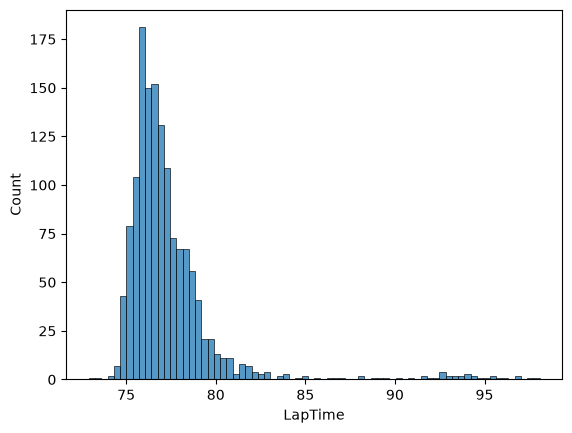

In [25]:
sns.histplot(session.laps['LapTime'].dt.total_seconds())

plt.show()

In [28]:
import requests
import fastf1

session = fastf1.get_session(2026, "Monaco", "R")

print(session.api_path)

/static/2026/2026-06-07_Monaco_Grand_Prix/2026-06-07_Race/


In [29]:
base = f"https://livetiming.formula1.com{session.api_path}"

for filename in [
    "SessionInfo.jsonStream",
    "TimingData.jsonStream",
    "CarData.z.jsonStream",
    "Position.z.jsonStream",
]:
    r = requests.get(
        base + filename,
        headers={"User-Agent": "BestHTTP"}
    )

    print(filename, r.status_code, len(r.content))

SessionInfo.jsonStream 403 919


KeyboardInterrupt: 